# Estimating pi, logarithms, and e with random points

Here is the idea: scatter 10,000 random points across the square $[-1, 1] \times [-1, 1]$ and count how many land inside the unit circle. Since the circle takes up $\pi / 4$ of the square, multiplying that fraction by four gives us an estimate of $\pi$.

In [1]:
%matplotlib inline

import math
import random

from matplotlib import pyplot as plt

SEED = 42
NUM_POINTS = 10_000
rng = random.Random(SEED)

points = [
    (rng.uniform(-1, 1), rng.uniform(-1, 1))
    for _ in range(NUM_POINTS)
]
inside_circle = [x**2 + y**2 <= 1 for x, y in points]
points_inside = sum(inside_circle)
pi_estimate = 4 * points_inside / NUM_POINTS
absolute_error = abs(pi_estimate - math.pi)

print(f"Points in the circle: {points_inside:,} / {NUM_POINTS:,}")
print(f"Our estimate of pi: {pi_estimate:.4f}")
print(f"Difference from math.pi: {absolute_error:.6f}")

Points in the circle: 7,848 / 10,000
Our estimate of pi: 3.1392
Difference from math.pi: 0.002393


Because the points are random, the estimate will not be exact. With more points it usually gets closer to $\pi$. The plot below makes the experiment visible: blue points landed inside the circle, while orange points missed it.

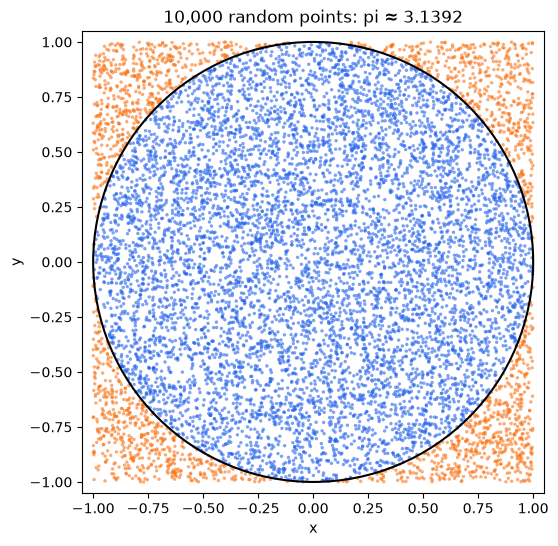

In [2]:
x_values = [x for x, _ in points]
y_values = [y for _, y in points]
colors = ["#2563eb" if is_inside else "#f97316" for is_inside in inside_circle]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x_values, y_values, c=colors, s=6, alpha=0.6, linewidths=0)
ax.add_patch(plt.Circle((0, 0), 1, fill=False, color="black", linewidth=1.5))
ax.set(
    xlim=(-1.05, 1.05),
    ylim=(-1.05, 1.05),
    xlabel="x",
    ylabel="y",
    title=f"{NUM_POINTS:,} random points: pi ≈ {pi_estimate:.4f}",
)
ax.set_aspect("equal")
plt.show()

## Trying the same idea for $\ln(x)$

The natural logarithm is the integral $\ln(x) = \int_1^x 1/t\,dt$. For a value above 1, this is just the area below $1/t$. I used a rectangle with height 1 and counted random points below the curve, almost like counting the points inside the circle.

In [3]:
def estimate_ln(value, num_points, random_generator):
    if value <= 0:
        raise ValueError("ln is only defined for positive values")
    if num_points <= 0:
        raise ValueError("num_points has to be positive")

    if value == 1:
        return 0.0, 0.0

    # Below 1 the integral goes the other way, so I flip it first.
    if value < 1:
        estimate, standard_error = estimate_ln(
            1 / value, num_points, random_generator
        )
        return -estimate, standard_error

    width = value - 1
    hits = 0

    for _ in range(num_points):
        x = random_generator.uniform(1, value)
        y = random_generator.random()
        if y <= 1 / x:
            hits += 1

    hit_rate = hits / num_points
    estimate = width * hit_rate
    standard_error = width * math.sqrt(
        hit_rate * (1 - hit_rate) / num_points
    )
    return estimate, standard_error


LOG_POINTS = 50_000
log_rng = random.Random(SEED + 1)

for value in (0.5, 2, 3, 10):
    log_estimate, log_error = estimate_ln(value, LOG_POINTS, log_rng)
    print(
        f"ln({value}) ≈ {log_estimate:.4f}  "
        f"(math.log: {math.log(value):.4f}, rough SE: {log_error:.4f})"
    )

ln(0.5) ≈ -0.6944  (math.log: -0.6931, rough SE: 0.0021)
ln(2) ≈ 0.6911  (math.log: 0.6931, rough SE: 0.0021)
ln(3) ≈ 1.1058  (math.log: 1.0986, rough SE: 0.0044)
ln(10) ≈ 2.3090  (math.log: 2.3026, rough SE: 0.0176)


## Getting Euler's number from the same area

Euler's number is the value where $\ln(x)=1$. I sampled the rectangle from 1 to 3, kept the points below $1/x$, and sorted them from left to right. Every accepted point stands for the same small piece of area, so the x-value where those pieces first add up to 1 gives an estimate of $e$.

In [4]:
def estimate_e(num_points, random_generator):
    if num_points <= 0:
        raise ValueError("num_points has to be positive")

    right_edge = 3.0  # e should be somewhere before this
    width = right_edge - 1
    accepted_x = []

    for _ in range(num_points):
        x = random_generator.uniform(1, right_edge)
        y = random_generator.random()
        if y <= 1 / x:
            accepted_x.append(x)

    accepted_x.sort()

    # Each accepted point represents this much of the whole rectangle.
    area_per_point = width / num_points
    points_needed = math.ceil(1 / area_per_point)
    if len(accepted_x) < points_needed:
        raise RuntimeError("not enough accepted points to reach area 1")

    return accepted_x[points_needed - 1], len(accepted_x)


E_POINTS = 1_000_000
e_rng = random.Random(SEED + 2)
e_estimate, accepted_points = estimate_e(E_POINTS, e_rng)

print(f"Points below 1/x: {accepted_points:,} / {E_POINTS:,}")
print(f"Our estimate of e: {e_estimate:.4f}")
print(f"Difference from math.e: {abs(e_estimate - math.e):.6f}")

Points below 1/x: 548,625 / 1,000,000
Our estimate of e: 2.7235
Difference from math.e: 0.005250


The last digits still move when the seed or number of points changes. The estimate of $e$ is also a bit indirect because it carries over the error from the estimated area, but it was a useful way to connect the three experiments.